### Agentic Rag

In [2]:
import os
from typing import List, Annotated
from pydantic import BaseModel
from langfuse.langchain import CallbackHandler
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain.chat_models import init_chat_model
from langchain_openai import OpenAIEmbeddings
from langchain_ollama import OllamaEmbeddings
from langchain_core.documents import Document
from langgraph.graph import StateGraph, END

In [ ]:
import os
from dotenv import load_dotenv

load_dotenv()

langfuse_trace = CallbackHandler()

llm_ollama = init_chat_model(
    model="granite4",
    model_provider="ollama"
)

llm_openai = init_chat_model(
    model="gpt-4.1-nano",
    # model="gpt-4o-mini",
    model_provider="openai"
)

llm_openai

ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.10', 'langchain-openai': '1.3.2'}}, output_version=None, profile={'name': 'GPT-4.1 nano', 'release_date': '2025-04-14', 'last_updated': '2025-04-14', 'open_weights': False, 'max_input_tokens': 1047576, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True, 'tool_call_streaming': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x0000023661FF16A0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x0000023661FF19D0>, root_client=<openai.OpenAI objec

In [7]:
### 1. Document Preprocessing
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2024-04-12-diffusion-video/"
]

loaders = [WebBaseLoader(url) for url in urls]
docs = []
for loader in loaders:
    docs.extend(loader.load())

docs

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final resu

In [8]:
### Recursive character text splitter an vectorstore.
splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50
)
split_docs = splitter.split_documents(docs)
embedding = OllamaEmbeddings(
    model="embeddinggemma"
)
vectorstore = FAISS.from_documents(split_docs, embedding)
retriever = vectorstore.as_retriever()

In [9]:
retriever.invoke("What are agents")

[Document(id='a208b7c3-a6e7-4ed2-be57-48bacce2c514', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, 

In [10]:
class RAGState(BaseModel):
    question: str
    retrieved_docs: List[Document] = []
    answer: str = ""

In [26]:
### 3. Langgraph Tools Nodes

def retrieve_docs(state: RAGState) -> RAGState:
    docs = retriever.invoke(state.question)
    return RAGState(question=state.question, retrieved_docs=docs)

def generate_answer(state: RAGState) -> RAGState:
    context = "\n\n".join(
        [doc.page_content for doc in state.retrieved_docs]
    )
    prompt = f"Answer the question based on the context.\n\nContext:\n{context}\n\nQuestion: {state.question}"
    response = llm_ollama.invoke(prompt, config={'callbacks': [langfuse_trace]})
    # response = llm_openai.invoke(prompt, config={'callbacks': [langfuse_trace]})
    return RAGState(
        question=state.question,
        retrieved_docs=state.retrieved_docs,
        answer=response.content
    )

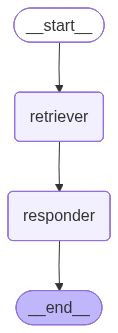

In [27]:
### 4. Build Graph

builder = StateGraph(RAGState)
builder.add_node("retriever", retrieve_docs)
builder.add_node("responder", generate_answer)

builder.set_entry_point("retriever")
builder.add_edge("retriever", "responder")
builder.add_edge("responder", END)

graph = builder.compile()

graph

In [ ]:
### Run the agentic RaG openai to compare output with ollama model

if __name__ == '__main__':
    user_question = "What is the concept of agent loop in autonomous agents?"
    initial_state = RAGState(question=user_question)
    final_state = graph.invoke(initial_state, config={"callbacks": [langfuse_trace]})
    print("\n Final answer:\n", final_state["answer"])


 Final answer:
 The concept of an agent loop in autonomous agents refers to the ongoing cycle where the agent perceives its environment, processes the information (often using an LLM or other AI components), makes decisions or plans actions, executes those actions, and then repeats the cycle. This loop allows the autonomous agent to continuously adapt, learn from its environment and experiences, and improve its performance over time. In systems like AutoGPT, the agent loop involves tasks such as goal setting, planning, executing sub-tasks, self-reflection, and adjusting strategies based on outcomes, enabling the agent to operate independently and handle complex real-world tasks through iterative refinement.


In [30]:
### 5. Run the agentic RaG
if __name__ == '__main__':
    user_question = "What is the concept of agent loop in autonomous agents?"
    initial_state = RAGState(question=user_question)
    final_state = graph.invoke(initial_state, config={"callbacks": [langfuse_trace]})
    print("\n Final answer:\n", final_state["answer"])


 Final answer:
 Based on the provided context, there is no explicit definition for a concept specifically labeled as an "**agent loop**." However, **Self-Reflection** is described as the mechanism that allows autonomous agents to improve iteratively, which closely mirrors the functioning of an agent loop in this system. Specifically:

*   Self-reflection enables agents to refine past action decisions and correct previous mistakes through trial and error.
*   In LLM-powered systems (such as AutoGPT), this iterative process is vital for real-world tasks where perfect information or a single pass isn't possible, treating the agent more like an interactive problem solver than just a copy writer or story generator.
